# Deep Q-Networks (DQN) and Extensions

## Why Deep RL?

Tabular Q-learning breaks down when the state space is huge (e.g., Atari pixels: $84 \times 84 \times 4 = 28{,}224$ dimensional). We approximate $Q(s,a)$ with a neural network $Q(s,a;\theta)$.

---

## DQN (Deep Q-Network)

**Key innovations** by DeepMind (2013, 2015):
1. **Experience Replay Buffer** store transitions $(s,a,r,s')$, sample random mini-batches → breaks correlations
2. **Target Network** $\theta^-$ separate, periodically updated copy → stabilizes training

### DQN Loss

$$L(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}}\left[\left(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta^-)}_{\text{TD target}} - Q(s,a;\theta)\right)^2\right]$$

Parameters $\theta^-$ (target net) are frozen during mini-batch updates and synced every $C$ steps.

---

## Double DQN

DQN overestimates Q-values because $\max$ is both **selecting** and **evaluating** the same network.

**Fix**: Use online network to **select** action, target network to **evaluate**:

$$y = r + \gamma Q\left(s', \arg\max_{a'}Q(s',a';\theta); \theta^-\right)$$

---

## Dueling DQN

Separate the Q-function into **value** $V(s)$ and **advantage** $A(s,a)$:

$$Q(s,a;\theta) = V(s;\theta) + A(s,a;\theta) - \frac{1}{|\mathcal{A}|}\sum_{a'}A(s,a';\theta)$$

The mean subtraction ensures identifiability: $V$ captures state quality, $A$ captures relative action quality.

---

## Prioritized Experience Replay (PER)

Sample transitions with higher TD error more frequently:

$$P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}, \quad p_i = |\delta_i| + \epsilon$$

Importance sampling weights to correct bias:

$$w_i = \left(\frac{1}{N \cdot P(i)}\right)^\beta$$

---

## Noisy Networks

Replace ε-greedy with **parametric noise** in network weights for exploration:

$$y = (\mu^w + \sigma^w \odot \epsilon^w)x + (\mu^b + \sigma^b \odot \epsilon^b)$$

The noise parameters $\sigma$ are learned exploration adapts over time.

---

## Rainbow DQN

Combines 6 improvements into one agent:

| Component | Benefit |
|-----------|----------|
| Double DQN | Removes overestimation bias |
| Dueling Networks | Better value estimation |
| Prioritized Replay | More efficient learning |
| Multi-step Returns | Better credit assignment |
| Distributional RL (C51) | Models return distribution |
| Noisy Networks | Better exploration |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# ─── Replay Buffer ───
class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s), np.array(a), np.array(r, dtype=np.float32),
                np.array(s2), np.array(d, dtype=np.float32))

    def __len__(self): return len(self.buffer)


# ─── Q-Network ───
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return self.net(x)


# ─── DQN Agent ───
class DQNAgent:
    def __init__(self, obs_dim, n_actions, lr=1e-3, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 batch_size=64, target_update=100):
        self.n_actions     = n_actions
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size    = batch_size
        self.target_update = target_update
        self.steps         = 0

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.q_net      = QNetwork(obs_dim, n_actions).to(self.device)
        self.target_net = QNetwork(obs_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay    = ReplayBuffer()

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.q_net(s).argmax().item()

    def train(self):
        if len(self.replay) < self.batch_size:
            return 0.0
        s, a, r, s2, done = self.replay.sample(self.batch_size)
        s    = torch.FloatTensor(s).to(self.device)
        a    = torch.LongTensor(a).to(self.device)
        r    = torch.FloatTensor(r).to(self.device)
        s2   = torch.FloatTensor(s2).to(self.device)
        done = torch.FloatTensor(done).to(self.device)

        # Current Q values
        q_vals = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Target Q values (Double DQN)
        with torch.no_grad():
            next_a   = self.q_net(s2).argmax(1)             # select with online
            q_next   = self.target_net(s2).gather(1, next_a.unsqueeze(1)).squeeze(1)  # eval with target
            q_target = r + self.gamma * q_next * (1 - done)

        loss = nn.MSELoss()(q_vals, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10)
        self.optimizer.step()

        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # Sync target network
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

print("DQN Agent defined. Device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

DQN Agent defined. Device: cpu


Episode  50 | Reward: 125.2 | ε: 0.010


Episode 100 | Reward: 259.8 | ε: 0.010


Episode 150 | Reward: 413.5 | ε: 0.010


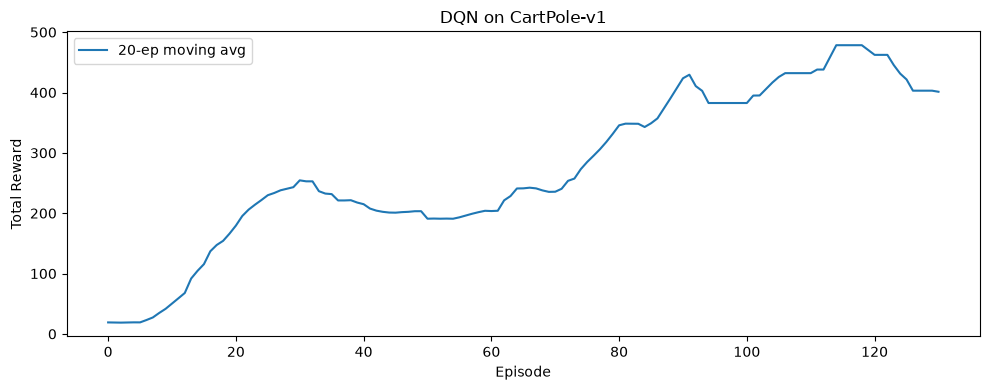

In [2]:
# ─── Train DQN on CartPole-v1 ───
try:
    import gymnasium as gym
    import matplotlib.pyplot as plt

    env     = gym.make('CartPole-v1')
    obs_dim = env.observation_space.shape[0]  # 4
    n_acts  = env.action_space.n              # 2
    agent   = DQNAgent(obs_dim, n_acts)

    episode_rewards, losses = [], []
    N_EPISODES = 150  # reduced for CPU runtime

    for ep in range(N_EPISODES):
        obs, _ = env.reset()
        total_r = 0
        for _ in range(500):
            a = agent.act(obs)
            next_obs, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            agent.replay.push(obs, a, r, next_obs, done)
            loss = agent.train()
            obs = next_obs
            total_r += r
            if done: break
        episode_rewards.append(total_r)
        if (ep+1) % 50 == 0:
            print(f"Episode {ep+1:3d} | Reward: {np.mean(episode_rewards[-50:]):.1f} | ε: {agent.epsilon:.3f}")

    env.close()

    plt.figure(figsize=(10,4))
    window = 20
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, label=f'{window}-ep moving avg')
    plt.xlabel('Episode'); plt.ylabel('Total Reward')
    plt.title('DQN on CartPole-v1')
    plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("Install: pip install gymnasium torch")

## Additional Learning Resources

### Papers
- **DQN** Playing Atari with Deep Reinforcement Learning: https://arxiv.org/abs/1312.5602
- **Human-level control through DRL** (Nature 2015): https://www.nature.com/articles/nature14236
- **Double DQN**: https://arxiv.org/abs/1509.06461
- **Dueling DQN**: https://arxiv.org/abs/1511.06581
- **Prioritized Experience Replay**: https://arxiv.org/abs/1511.05952
- **Noisy Networks**: https://arxiv.org/abs/1706.10295
- **Rainbow DQN**: https://arxiv.org/abs/1710.02298

### Courses
- **Hugging Face RL Course Unit 3** (DQN): https://huggingface.co/learn/deep-rl-course/unit3
- **Spinning Up in Deep RL**: https://spinningup.openai.com/

### Libraries
- **Stable-Baselines3 DQN**: https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html
- **CleanRL** (clean DQN implementation): https://github.com/vwxyzjn/cleanrl